## Purpose:
    This notebook evaluates route prediction accuracy and statistical significance
    across four route prediction methods: shortest-path baseline, Basic Markov,
    Conditional Markov, and LSTM.

# Main procedures:
    1. Load observed and predicted route sequences for each split size.
    2. Compute Jaccard similarity between observed and predicted node sets.
    3. Compute Levenshtein distance between observed and predicted node sequences.
    4. Save accuracy metrics as CSV files.
    5. Visualize model-level metric distributions.
    6. Perform Friedman tests and pairwise Wilcoxon signed-rank tests with Holm correction.

## Ploting Figure
### Same plotting code as ../For_test/Code10_accuracy.ipynb
### The visualization section uses the same plotting code as ../For_test/Code10_accuracy.ipynb, but the input data are replaced with the final route prediction results based on the actual validation dataset.

In [ ]:
import numpy as np
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
import os
import glob

In [ ]:
def jaccard_similarity(base, compare_set):
    intersection = len(base.intersection(compare_set))
    union = len(base.union(compare_set))
    return intersection / union

def levenshtein(s1, s2):
    len1, len2 = len(s1), len(s2)
    dp = np.zeros((len1 + 1, len2 + 1), dtype=int)

    for i in range(len1 + 1):
        dp[i][0] = i
    for j in range(len2 + 1):
        dp[0][j] = j

    for i in range(1, len1 + 1):
        for j in range(1, len2 + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1,     # delete
                           dp[i][j-1] + 1,     # insert
                           dp[i-1][j-1] + cost)  # substitute

    return dp[len1][len2]

## Load Data

In [ ]:
for i in range(8, 17, 4):
    shortcut_pd = pd.read_csv(f'./trajectory/shortcut_prediction_route/shortcut_path_{i}.csv')
    LSTM_pd = pd.read_csv(f'./trajectory/prediction_LSTM/LSTM_fix_{i}_by1.csv')
    gps_pd = pd.read_csv(f'./trajectory/merged_routes_by_{i}.csv')
    marcov_pd = pd.read_csv(f'./trajectory/prediction_markov/markov_route_{i}.csv')
    marcov_2_pd = pd.read_csv(f'./trajectory/prediction_markov_2/markov2_route_{i}.csv')

    similarity_sc_all = []
    levenshtein_distnace_sc_all = []
    similarity_LSTM_all = []
    levenshtein_distnace_LSTM_all = []
    similarity_marcov_all = []
    levenshtein_distnace_marcov_all = []
    similarity_marcov_2_all = []
    levenshtein_distnace_marcov_2_all = []

    for j in range(len(gps_pd)):
        # GPS
        gps_route = ast.literal_eval(gps_pd.iloc[j, 1])
        gps_name = gps_pd.iloc[j, 0]
        # Shortest path
        shortcut_route = ast.literal_eval(shortcut_pd[shortcut_pd['name'] == gps_name]['path'].iloc[0])
        # LSTM
        LSTM_route = ast.literal_eval(LSTM_pd[LSTM_pd['name'] == gps_name]['path'].iloc[0])
        # Markov
        marcov_route = ast.literal_eval(marcov_pd[marcov_pd['travel_name'] == gps_name]['predicted_route'].iloc[0])
        # Attribute Conditional Markov
        marcov_2_route = ast.literal_eval(marcov_2_pd[marcov_2_pd['travel_name'] == gps_name]['predicted_route'].iloc[0])
        
        # calculate similarity and distance
        base = set(gps_route)
        compare_sc = set(shortcut_route)
        compare_LSTM = set(LSTM_route)
        compare_marcov = set(marcov_route)
        compare_marcov_2 = set(marcov_2_route)
        
        similarity_sc = jaccard_similarity(base, compare_sc)
        levenshtein_distnace_sc = levenshtein(gps_route, shortcut_route)
        similarity_LSTM = jaccard_similarity(base, compare_LSTM)
        levenshtein_distnace_LSTM = levenshtein(gps_route, LSTM_route)
        similarity_marcov = jaccard_similarity(base, compare_marcov)
        levenshtein_distnace_marcov = levenshtein(gps_route, marcov_route)
        similarity_marcov_2 = jaccard_similarity(base, compare_marcov_2)
        levenshtein_distnace_marcov_2 = levenshtein(gps_route, marcov_2_route)

        similarity_sc_all.append(similarity_sc)
        levenshtein_distnace_sc_all.append(levenshtein_distnace_sc)
        similarity_LSTM_all.append(similarity_LSTM)
        levenshtein_distnace_LSTM_all.append(levenshtein_distnace_LSTM)
        similarity_marcov_all.append(similarity_marcov)
        levenshtein_distnace_marcov_all.append(levenshtein_distnace_marcov)
        similarity_marcov_2_all.append(similarity_marcov_2)
        levenshtein_distnace_marcov_2_all.append(levenshtein_distnace_marcov_2)
        
    data = {
        'similarity_sc': similarity_sc_all,
        'levenshtein_sc': levenshtein_distnace_sc_all,
        'similarity_LSTM': similarity_LSTM_all,
        'levenshtein_LSTM': levenshtein_distnace_LSTM_all,
        'similarity_markov': similarity_marcov_all,
        'levenshtein_markov': levenshtein_distnace_marcov_all
        ,'similarity_markov_2': similarity_marcov_2_all,
        'levenshtein_markov_2': levenshtein_distnace_marcov_2_all
        }

    df = pd.DataFrame(data)
    df.to_csv(f'./accuracy/accuracy_ver_last_{i}.csv', index=False)

## Figure 7

/tmp/ipykernel_1507317/911669610.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


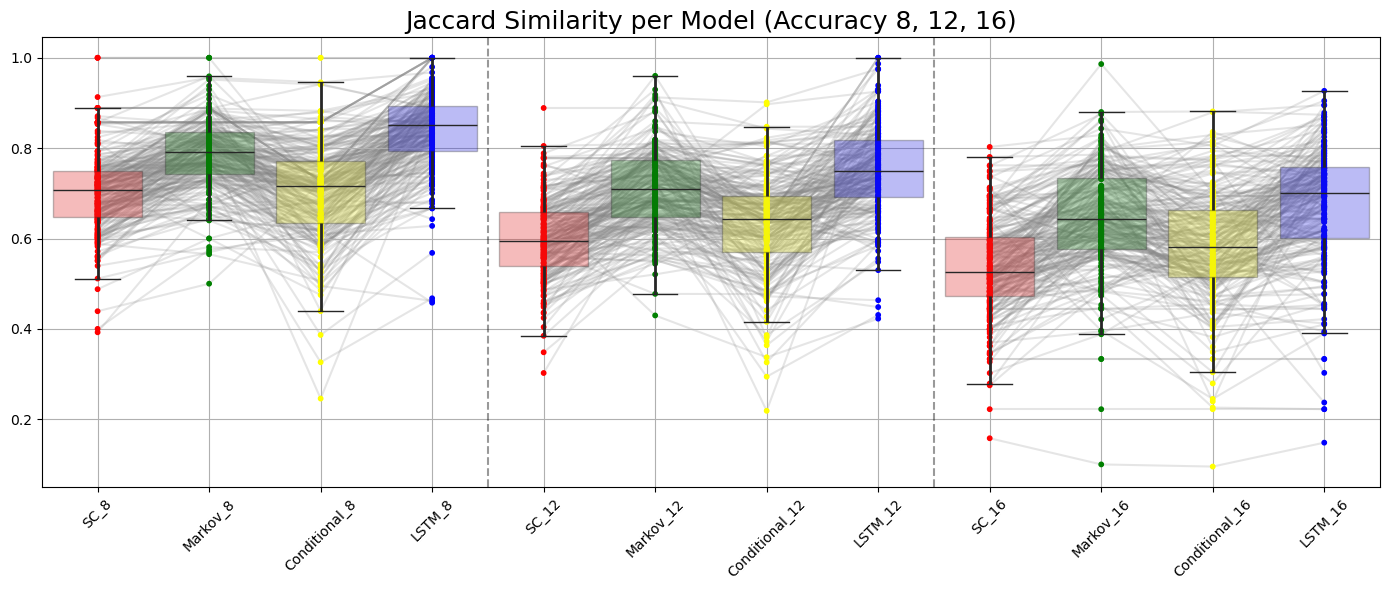

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_long_all = []
pair_lines = []

for i in range(8, 17, 4):  # 8, 12, 16
    file_path = f'./accuracy/accuracy_ver_last_{i}.csv'
    if os.path.exists(file_path):
        df_tmp = pd.read_csv(file_path)

        df_tmp = df_tmp.iloc[:, [0, 2, 4, 6]]
        df_tmp.columns = [f'SC_{i}', f'LSTM_{i}', f'Markov_{i}', f'Markov_2_{i}']
        df_tmp['SampleID'] = df_tmp.index

        df_long = df_tmp.melt(
            id_vars='SampleID',
            var_name='Method',
            value_name='Distance'
        )
        df_long_all.append(df_long)

        for _, row in df_tmp.iterrows():
            pair_lines.append({
                'x': [f'SC_{i}', f'Markov_{i}', f'Markov_2_{i}', f'LSTM_{i}'],
                'y': [row[f'SC_{i}'], row[f'Markov_{i}'], row[f'Markov_2_{i}'], row[f'LSTM_{i}']]
            })
    else:
        print(f"[!] No file found: {file_path}")

if df_long_all:
    df_long_all = pd.concat(df_long_all, ignore_index=True)

    plt.figure(figsize=(14, 6), facecolor="none")
    ax = plt.gca()
    ax.set_facecolor("none")

    method_order = ['SC', 'Markov', 'Markov_2', 'LSTM']

    xticks = sorted(
        df_long_all['Method'].unique(),
        key=lambda x: (
            int(x.split('_')[-1]),
            method_order.index(x.rsplit('_', 1)[0])
        )
    )

    xmap = {label: idx for idx, label in enumerate(xticks)}
    num_groups = len(xticks) // 4

    for line in pair_lines:
        x_vals = [xmap[m] for m in line['x']]
        y_vals = line['y']
        plt.plot(x_vals, y_vals, color='gray', alpha=0.2, zorder=1)
        plt.scatter(
            x_vals, y_vals,
            color=['red', 'green', 'yellow', 'blue'],
            s=10,
            zorder=2
        )

    for g in range(1, num_groups):
        plt.axvline(x=g * 4 - 0.5, color='black', linestyle='--', alpha=0.4)

    sns.boxplot(
        data=df_long_all,
        x='Method',
        y='Distance',
        order=xticks,
        palette=['red', 'green', 'yellow', 'blue'] * num_groups,
        boxprops=dict(alpha=0.3),
        showcaps=True,
        whiskerprops={'linewidth': 2},
        fliersize=0
    )

    plt.title("Jaccard Similarity per Model (Accuracy 8, 12, 16)", fontsize=18)
    plt.xlabel("")
    plt.ylabel("")

    labels = [lab.replace("Markov_2", "Conditional") for lab in xticks]
    ax.set_xticks(range(len(xticks)))
    ax.set_xticklabels(labels, rotation=45)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig("similarity.png", transparent=True, dpi=300)
    plt.show()

## Figure 8

/tmp/ipykernel_1737017/1137728010.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


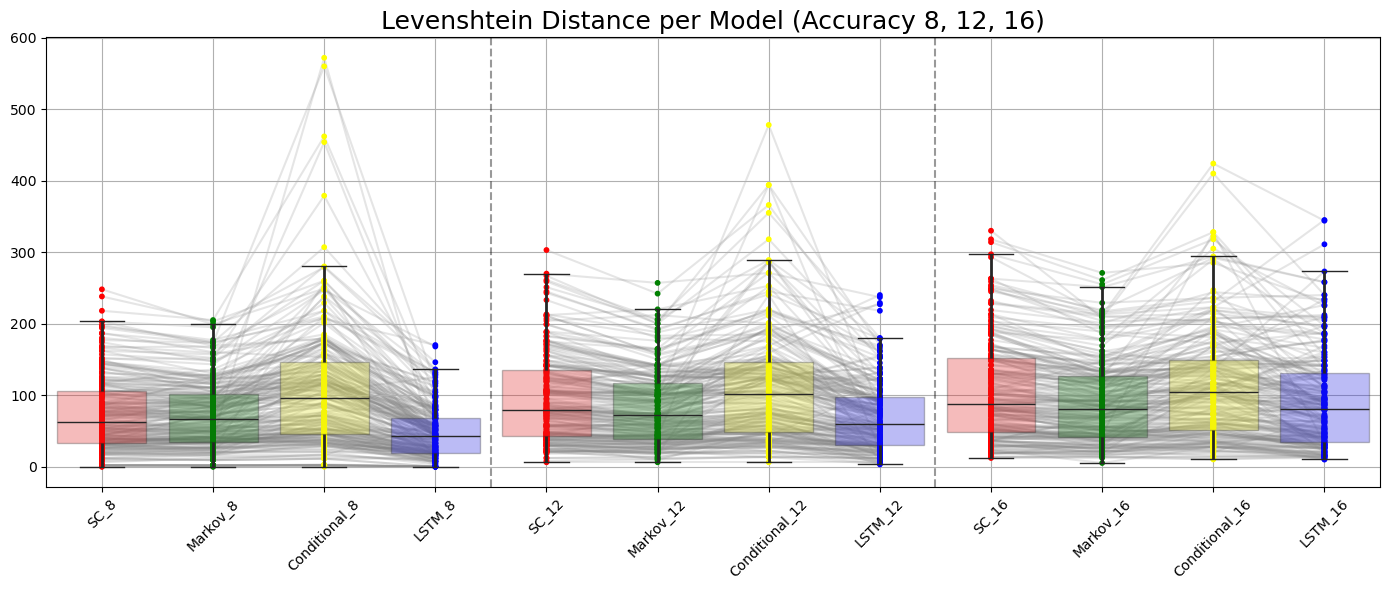

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
    
df_long_all = []
pair_lines = []

for i in range(8, 17, 4):
    file_path = f'./accuracy/accuracy_ver_last_{i}.csv'
    if os.path.exists(file_path):
        df_tmp = pd.read_csv(file_path)

        df_tmp = df_tmp.iloc[:, [1, 3, 5, 7]]
        df_tmp.columns = [f'SC_{i}', f'LSTM_{i}', f'Markov_{i}', f'Markov_2_{i}']
        df_tmp['SampleID'] = df_tmp.index

        df_long = df_tmp.melt(
            id_vars='SampleID',
            var_name='Method',
            value_name='Distance'
        )
        df_long_all.append(df_long)

        for _, row in df_tmp.iterrows():
            pair_lines.append({
                'x': [f'SC_{i}', f'Markov_{i}', f'Markov_2_{i}', f'LSTM_{i}'],
                'y': [row[f'SC_{i}'], row[f'Markov_{i}'], row[f'Markov_2_{i}'], row[f'LSTM_{i}']]
            })
    else:
        print(f"[!] No file found: {file_path}")

if df_long_all:
    df_long_all = pd.concat(df_long_all, ignore_index=True)

    plt.figure(figsize=(14, 6), facecolor="none")
    ax = plt.gca()
    ax.set_facecolor("none")

    method_order = ['SC', 'Markov', 'Markov_2', 'LSTM']

    xticks = sorted(
        df_long_all['Method'].unique(),
        key=lambda x: (
            int(x.split('_')[-1]),
            method_order.index(x.rsplit('_', 1)[0])
        )
    )

    xmap = {label: idx for idx, label in enumerate(xticks)}
    num_groups = len(xticks) // 4

    for line in pair_lines:
        x_vals = [xmap[m] for m in line['x']]
        y_vals = line['y']
        plt.plot(x_vals, y_vals, color='gray', alpha=0.2, zorder=1)
        plt.scatter(
            x_vals, y_vals,
            color=['red', 'green', 'yellow', 'blue'],
            s=10,
            zorder=2
        )

    for g in range(1, num_groups):
        plt.axvline(x=g * 4 - 0.5, color='black', linestyle='--', alpha=0.4)

    sns.boxplot(
        data=df_long_all,
        x='Method',
        y='Distance',
        order=xticks,
        palette=['red', 'green', 'yellow', 'blue'] * num_groups,
        boxprops=dict(alpha=0.3),
        showcaps=True,
        whiskerprops={'linewidth': 2},
        fliersize=0
    )

    plt.title("Levenshtein Distance per Model (Accuracy 8, 12, 16)", fontsize=18)

    plt.xlabel("")
    plt.ylabel("")

    labels = [lab.replace("Markov_2", "Conditional") for lab in xticks]
    ax.set_xticks(range(len(xticks)))
    ax.set_xticklabels(labels, rotation=45)

    plt.grid(True)
    plt.tight_layout()

    plt.savefig("levenshtein.png", transparent=True, dpi=300)
    plt.show()

## Statistical significance test
### The statistical significance testing section is newly added in this notebook.

In [2]:
import itertools
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

# path
files = {
    "split_8": "./accuracy/accuracy_ver_last_8.csv",
    "split_12": "./accuracy/accuracy_ver_last_12.csv",
    "split_16": "./accuracy/accuracy_ver_last_16.csv",
}

# column mapping for each metric and model
metrics = {
    "Jaccard": {
        "direction": "higher",
        "cols": {
            "Dijkstra": "similarity_sc",
            "Markov": "similarity_markov",
            "Markov2": "similarity_markov_2",
            "LSTM": "similarity_LSTM",
        },
    },
    "Levenshtein": {
        "direction": "lower",
        "cols": {
            "Dijkstra": "levenshtein_sc",
            "Markov": "levenshtein_markov",
            "Markov2": "levenshtein_markov_2",
            "LSTM": "levenshtein_LSTM",
        },
    },
}


def p_fmt(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"


for split, path in files.items():
    df = pd.read_csv(path)

    print("\n" + "=" * 80)
    print(split)
    print("=" * 80)

    for metric_name, info in metrics.items():
        cols = info["cols"]
        direction = info["direction"]

        data = df[list(cols.values())].dropna()

        print(f"\n[{metric_name}]")
        print(f"N = {len(data)}")

        # 1) Descriptive statistics
        print("\nDescriptive statistics")
        for model, col in cols.items():
            print(
                f"{model:10s} "
                f"mean={data[col].mean():.4f}, "
                f"median={data[col].median():.4f}"
            )

        # 2) Friedman test
        arrays = [data[col].values for col in cols.values()]
        stat, p = friedmanchisquare(*arrays)

        print("\nFriedman test")
        print(f"chi-square = {stat:.3f}, p = {p_fmt(p)}")

        # 3) Pairwise Wilcoxon signed-rank test
        comparisons = []
        raw_pvals = []

        for m1, m2 in itertools.combinations(cols.keys(), 2):
            x = data[cols[m1]].values
            y = data[cols[m2]].values

            if (x == y).all():
                w_stat, raw_p = None, 1.0
            else:
                w_stat, raw_p = wilcoxon(x, y, alternative="two-sided")

            comparisons.append((m1, m2, w_stat, raw_p))
            raw_pvals.append(raw_p)

        # 4) Holm correction
        reject, p_holm, _, _ = multipletests(
            raw_pvals,
            alpha=0.05,
            method="holm"
        )

        print("\nPairwise Wilcoxon signed-rank test + Holm correction")
        for i, (m1, m2, w_stat, raw_p) in enumerate(comparisons):
            mean1 = data[cols[m1]].mean()
            mean2 = data[cols[m2]].mean()

            if not reject[i]:
                better = "Not significant"
            else:
                if direction == "higher":
                    better = m1 if mean1 > mean2 else m2
                else:
                    better = m1 if mean1 < mean2 else m2

            print(
                f"{m1:10s} vs {m2:10s} | "
                f"raw p = {p_fmt(raw_pvals[i])}, "
                f"Holm p = {p_fmt(p_holm[i])}, "
                f"significant = {reject[i]}, "
                f"better = {better}"
            )


split_8

[Jaccard]
N = 224

Descriptive statistics
Dijkstra   mean=0.7031, median=0.7063
Markov     mean=0.7866, median=0.7906
Markov2    mean=0.7031, median=0.7157
LSTM       mean=0.8409, median=0.8505

Friedman test
chi-square = 389.241, p = <0.001

Pairwise Wilcoxon signed-rank test + Holm correction
Dijkstra   vs Markov     | raw p = <0.001, Holm p = <0.001, significant = True, better = Markov
Dijkstra   vs Markov2    | raw p = 0.467, Holm p = 0.467, significant = False, better = Not significant
Dijkstra   vs LSTM       | raw p = <0.001, Holm p = <0.001, significant = True, better = LSTM
Markov     vs Markov2    | raw p = <0.001, Holm p = <0.001, significant = True, better = Markov
Markov     vs LSTM       | raw p = <0.001, Holm p = <0.001, significant = True, better = LSTM
Markov2    vs LSTM       | raw p = <0.001, Holm p = <0.001, significant = True, better = LSTM

[Levenshtein]
N = 224

Descriptive statistics
Dijkstra   mean=73.8661, median=62.0000
Markov     mean=71.2991, medi